Database ready: 20871 panels (17741 train / 3130 val).
Generating train and validation datasets...


[I 2026-07-17 16:54:30,426] A new study created in memory with name: no-name-add71db5-5118-4f3d-8e11-55024a16a06d


Train points: 100000 | Val points: 16000

Starting Bayesian hyperparameter search (Optuna / TPE)...


/usr/local/lib/python3.12/dist-packages/optuna/progress_bar.py:47: ExperimentalWarning: Progress bar is experimental (supported from v1.2.0). The interface can change in the future.
  self._init_valid()


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-07-17 16:55:57,143] Trial 0 finished with value: 0.0006908305687829853 and parameters: {'units1': 224, 'units2': 256, 'units3': 96, 'learning_rate': 0.0015751320499779737, 'decay_rate': 0.871842609661941, 'decay_steps': 400, 'batch_size': 1024, 'phys_weight_final': 0.005471975564178365, 'warmup_end': 20, 'ramp_end': 37}. Best is trial 0 with value: 0.0006908305687829853.
[I 2026-07-17 16:56:40,657] Trial 1 finished with value: 0.004766455024946481 and parameters: {'units1': 160, 'units2': 64, 'units3': 32, 'learning_rate': 0.0004059611610484307, 'decay_rate': 0.9234659004285133, 'decay_steps': 900, 'batch_size': 1024, 'phys_weight_final': 0.024899438865017734, 'warmup_end': 12, 'ramp_end': 36}. Best is trial 0 with value: 0.0006908305687829853.
[I 2026-07-17 16:57:32,295] Trial 2 finished with value: 0.025941001251339912 and parameters: {'units1': 128, 'units2': 160, 'units3': 80, 'learning_rate': 0.0001238513729886094, 'decay_rate': 0.9350562792662014, 'decay_steps': 400, 'bat

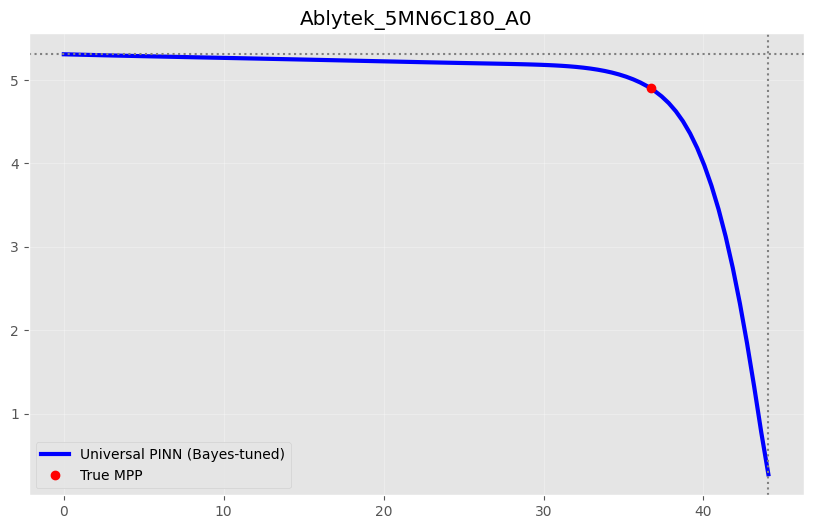

/tmp/ipykernel_57/1015086561.py:355: ExperimentalWarning: plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_optimization_history(study)


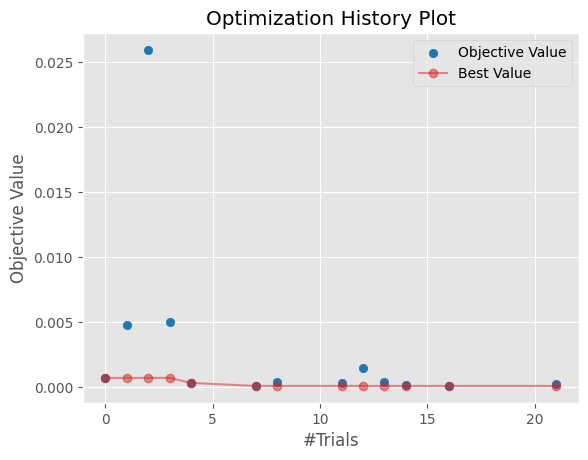

/tmp/ipykernel_57/1015086561.py:357: ExperimentalWarning: plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  optuna.visualization.matplotlib.plot_param_importances(study)


(Skipping Optuna plots: setting an array element with a sequence. The requested array would exceed the maximum number of dimension of 1.)


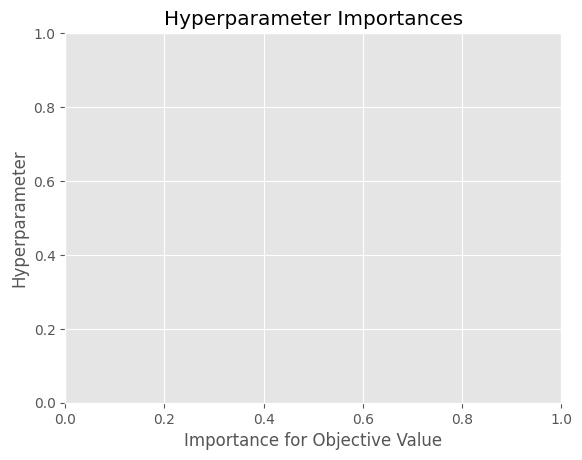

In [8]:
!pip install pvlib optuna

import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pvlib
from pvlib import pvsystem
from sklearn.preprocessing import RobustScaler
import optuna
from optuna.samplers import TPESampler
import os

os.makedirs("model", exist_ok=True)
pd.options.mode.chained_assignment = None

# =============================================================================
# 1. DATABASE
# =============================================================================
all_modules = pvlib.pvsystem.retrieve_sam('CECMod').T
df_db = all_modules[all_modules['Technology'].str.contains('Si', na=False)].copy()

dna_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref', 'R_s', 'R_sh_ref', 'N_s']
for col in dna_cols + ['V_oc_ref', 'I_sc_ref', 'V_mp_ref', 'I_mp_ref']:
    df_db[col] = pd.to_numeric(df_db[col], errors='coerce')

df_db = df_db[
    (df_db['I_o_ref'] > 1e-15) & (df_db['a_ref'] > 0.5) &
    (df_db['R_sh_ref'] > 10.0) & (df_db['I_sc_ref'] > 0.5) &
    (df_db['V_oc_ref'] > 10.0)
].dropna(subset=dna_cols)

df_db['I_o_ref_log'] = np.log10(df_db['I_o_ref'])
df_db['R_sh_ref_log'] = np.log10(df_db['R_sh_ref'])

fit_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref_log', 'R_s', 'R_sh_ref_log', 'N_s']

# --- Panel-level split BEFORE fitting the scaler, so validation panels are truly held out ---
rng = np.random.default_rng(42)
shuffled_idx = rng.permutation(len(df_db))
n_val_panels = max(20, int(0.15 * len(df_db)))
val_panel_idx = shuffled_idx[:n_val_panels]
train_panel_idx = shuffled_idx[n_val_panels:]

df_train_panels = df_db.iloc[train_panel_idx]
df_val_panels = df_db.iloc[val_panel_idx]

dna_scaler = RobustScaler()
dna_scaler.fit(df_train_panels[fit_cols])  # fit only on training panels, avoid leakage

print(f"Database ready: {len(df_db)} panels "
      f"({len(df_train_panels)} train / {len(df_val_panels)} val).")

# =============================================================================
# 2. DATA GENERATOR
# =============================================================================
def generate_pinn_data(source_df, n_panels=2500, pts=50, seed=None):
    X, y = [], []
    local_rng = np.random.default_rng(seed)
    indices = local_rng.choice(len(source_df), n_panels, replace=True)

    for idx in indices:
        row = source_df.iloc[idx]

        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]

        G = local_rng.uniform(200, 1100, pts)
        T_c = local_rng.uniform(15, 75, pts)

        try:
            IL, Io, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
                G, T_c, row['alpha_sc'], row['a_ref'], row['I_L_ref'],
                row['I_o_ref'], row['R_sh_ref'], row['R_s']
            )
            V_norm_axis = np.linspace(0, 1.0, pts)
            I_raw = pvsystem.i_from_v(V_norm_axis * row['V_oc_ref'], IL, Io, Rs, Rsh, nNsVth)

            for j in range(pts):
                if not np.isnan(I_raw[j]):
                    X.append([
                        G[j] / 1000.0, (T_c[j] - 25.0) / 100.0, V_norm_axis[j]
                    ] + dna_norm.tolist() + [
                        row['V_oc_ref'] / 50.0, row['I_sc_ref'] / 10.0
                    ])
                    y.append(max(0, I_raw[j] / row['I_sc_ref']))
        except Exception:
            continue

    return np.array(X, 'float32'), np.array(y, 'float32').reshape(-1, 1)


print("Generating train and validation datasets...")
X_train, y_train = generate_pinn_data(df_train_panels, n_panels=2500, pts=40, seed=1)
X_val, y_val = generate_pinn_data(df_val_panels, n_panels=400, pts=40, seed=2)
print(f"Train points: {len(X_train)} | Val points: {len(X_val)}")

# =============================================================================
# 3. MODEL / TRAIN-STEP FACTORY (parameterized so Optuna can control it)
# =============================================================================
def build_model(units1, units2, units3):
    return keras.Sequential([
        layers.InputLayer(shape=(12,)),
        layers.Dense(units1, activation='swish'),
        layers.Dense(units2, activation='swish'),
        layers.Dense(units3, activation='swish'),
        layers.Dense(1, activation='linear')  # linear output is crucial for PINNs
    ])


def make_train_step(model, optimizer):
    @tf.function
    def train_step(x, y_true, phys_weight):
        with tf.GradientTape(persistent=True) as tape:
            tape.watch(x)
            y_pred = model(x, training=True)

            grads_input = tape.gradient(y_pred, x)
            dI_dV = grads_input[:, 2:3]  # voltage is feature index 2

            loss_data = tf.reduce_mean(tf.square(y_true - y_pred))
            loss_monotonic = tf.reduce_mean(tf.square(tf.nn.relu(dI_dV)))

            total_loss = loss_data + (phys_weight * loss_monotonic)

        grads_weights = tape.gradient(total_loss, model.trainable_variables)
        del tape
        optimizer.apply_gradients(zip(grads_weights, model.trainable_variables))
        return loss_data, loss_monotonic

    return train_step


def phys_weight_for_epoch(epoch, warmup_end, ramp_end, final_weight):
    """Adaptive physics weight schedule, now tunable instead of hardcoded."""
    if epoch < warmup_end:
        return 0.0
    elif epoch < ramp_end:
        return final_weight * 0.2
    else:
        return final_weight


def _compute_val_metrics(model, X_va, y_va, monotonic_weight=0.05):
    """Returns (data_mse, monotonic_violation, combined_score) on validation data.

    data_mse: plain MSE between predicted and true normalized current.
    monotonic_violation: mean squared magnitude of any positive dI/dV slope
        (should be ~0 for a physically valid I-V curve; I always decreases
        with V, so dI/dV should be <= 0 everywhere).
    combined_score: what Optuna actually optimizes/prunes on, so a model
        that fits well but has visible non-monotonic wiggles is not treated
        as "the best" over one that fits almost as well with a clean curve.
    """
    X_va_tf = tf.convert_to_tensor(X_va, dtype=tf.float32)
    with tf.GradientTape() as tape:
        tape.watch(X_va_tf)
        y_pred = model(X_va_tf, training=False)
    grads = tape.gradient(y_pred, X_va_tf)
    dI_dV = grads[:, 2:3]  # voltage is feature index 2

    monotonic_violation = float(tf.reduce_mean(tf.square(tf.nn.relu(dI_dV))))
    data_mse = float(np.mean(np.square(y_va - y_pred.numpy())))
    combined_score = data_mse + monotonic_weight * monotonic_violation

    return data_mse, monotonic_violation, combined_score


# How heavily monotonicity violations count against the validation score.
# Scaled so that a "clean" model (near-zero violation) barely differs from
# pure data MSE, but a model with visible non-monotonic wiggles is penalized.
VAL_MONOTONIC_WEIGHT = 0.05


def train_model(params, epochs, X_tr, y_tr, X_va=None, y_va=None, verbose=False,
                 trial=None, report_every=5):
    """Builds, trains, and returns (model, val_metrics).

    val_metrics is a dict {'data_mse', 'monotonic_violation', 'combined_score'}
    (or None if no validation data is provided).

    If `trial` (an optuna.Trial) is passed, the combined score is computed and
    reported every `report_every` epochs so Optuna's pruner can actually cut
    unpromising trials short instead of only seeing one score at the very end.
    """
    model = build_model(params['units1'], params['units2'], params['units3'])

    lr_schedule = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=params['learning_rate'],
        decay_steps=params['decay_steps'],
        decay_rate=params['decay_rate'],
        staircase=True)
    optimizer = keras.optimizers.Adam(learning_rate=lr_schedule)
    train_step = make_train_step(model, optimizer)

    dataset = tf.data.Dataset.from_tensor_slices((X_tr, y_tr)) \
        .shuffle(100000).batch(params['batch_size'])

    for epoch in range(epochs):
        p_w = phys_weight_for_epoch(
            epoch, params['warmup_end'], params['ramp_end'], params['phys_weight_final']
        )
        l_d, l_p = [], []
        for xb, yb in dataset:
            d, p = train_step(xb, yb, tf.constant(p_w, dtype=tf.float32))
            l_d.append(d); l_p.append(p)

        if verbose and (epoch + 1) % 10 == 0:
            print(f"  epoch {epoch+1:<4} | data_loss={np.mean(l_d):.6f} "
                  f"| phys_loss={np.mean(l_p):.6f} | phys_w={p_w:.3f}")

        # --- Mid-training pruning check ---
        is_last_epoch = (epoch == epochs - 1)
        if trial is not None and X_va is not None:
            if ((epoch + 1) % report_every == 0) or is_last_epoch:
                _, _, interim_score = _compute_val_metrics(
                    model, X_va, y_va, monotonic_weight=VAL_MONOTONIC_WEIGHT
                )
                trial.report(interim_score, step=epoch)
                if trial.should_prune():
                    raise optuna.TrialPruned(
                        f"Pruned at epoch {epoch+1} (combined_score={interim_score:.6f})"
                    )

    val_metrics = None
    if X_va is not None:
        data_mse, monotonic_violation, combined_score = _compute_val_metrics(
            model, X_va, y_va, monotonic_weight=VAL_MONOTONIC_WEIGHT
        )
        val_metrics = {
            'data_mse': data_mse,
            'monotonic_violation': monotonic_violation,
            'combined_score': combined_score,
        }
        if verbose:
            print(f"  val: data_mse={data_mse:.6f} | monotonic_violation={monotonic_violation:.6f} "
                  f"| combined_score={combined_score:.6f}")

    return model, val_metrics

# =============================================================================
# 4. BAYESIAN OPTIMIZATION (Optuna, TPE sampler)
# =============================================================================
SEARCH_EPOCHS = 35   # short budget per trial to keep the search cheap
N_TRIALS = 25         # number of Bayesian-optimization trials

def objective(trial):
    params = {
        'units1': trial.suggest_int('units1', 64, 512, step=32),          # was 384 max -> widened
        'units2': trial.suggest_int('units2', 32, 256, step=32),
        'units3': trial.suggest_int('units3', 16, 128, step=16),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 1e-2, log=True),  # was 5e-3 max -> widened
        'decay_rate': trial.suggest_float('decay_rate', 0.85, 0.99),
        'decay_steps': trial.suggest_int('decay_steps', 100, 2000, step=100),  # was 300 min -> widened
        'batch_size': trial.suggest_categorical('batch_size', [512, 1024, 2048, 4096]),
        'phys_weight_final': trial.suggest_float('phys_weight_final', 0.005, 0.4, log=True),  # was 0.2 max -> widened
        'warmup_end': trial.suggest_int('warmup_end', 5, 20),
        'ramp_end': trial.suggest_int('ramp_end', 20, 40),
    }
    # keep the schedule sane: ramp_end must exceed warmup_end
    if params['ramp_end'] <= params['warmup_end']:
        params['ramp_end'] = params['warmup_end'] + 5

    _, val_metrics = train_model(
        params, epochs=SEARCH_EPOCHS,
        X_tr=X_train, y_tr=y_train, X_va=X_val, y_va=y_val,
        verbose=False,
        trial=trial,          # enables mid-training reporting + pruning
        report_every=5,       # check every 5 epochs instead of only at the end
    )

    return val_metrics['combined_score']


print("\nStarting Bayesian hyperparameter search (Optuna / TPE)...")
study = optuna.create_study(
    direction='minimize',
    sampler=TPESampler(seed=42),
    pruner=optuna.pruners.MedianPruner(
        n_startup_trials=5,    # don't prune until 5 trials have fully completed
        n_warmup_steps=10,     # don't prune before epoch 10 within a trial
        interval_steps=5,      # matches report_every in train_model
    )
)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print("\nBest trial:")
print(f"  Validation combined score: {study.best_value:.6f}  "
      f"(= data_mse + {VAL_MONOTONIC_WEIGHT} * monotonic_violation)")
print("  Params:")
for k, v in study.best_params.items():
    print(f"    {k}: {v}")

# =============================================================================
# 5. FINAL TRAINING WITH BEST HYPERPARAMETERS (full epoch budget)
# =============================================================================
best_params = dict(study.best_params)
if best_params['ramp_end'] <= best_params['warmup_end']:
    best_params['ramp_end'] = best_params['warmup_end'] + 5

print("\nRetraining final model with best hyperparameters (150 epochs)...")
model, final_val_metrics = train_model(
    best_params, epochs=150,
    X_tr=X_train, y_tr=y_train, X_va=X_val, y_va=y_val,
    verbose=True
)
model.save_weights("model/universal_pinn_weights.weights.h5")

print(f"\nFinal held-out validation:")
print(f"  data_mse             = {final_val_metrics['data_mse']:.6f}")
print(f"  monotonic_violation  = {final_val_metrics['monotonic_violation']:.6f}")
print(f"  combined_score       = {final_val_metrics['combined_score']:.6f}")

# =============================================================================
# 6. TEST / VISUALIZE
# =============================================================================
def test_panel(panel_name=None):
    if panel_name is not None and panel_name in df_db.index:
        row = df_db.loc[panel_name]
    else:
        row = df_db.sample(1, random_state=None).iloc[0]
        panel_name = row.name

    dna_vals = [row[c] for c in fit_cols]
    dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
    dna_norm = dna_scaler.transform(dna_df)[0]

    v_sweep = np.linspace(0, 1.0, 100)
    X_test = []
    for v in v_sweep:
        X_test.append([1.0, 0.0, v] + dna_norm.tolist() +
                       [row['V_oc_ref'] / 50.0, row['I_sc_ref'] / 10.0])

    y_pred = model.predict(np.array(X_test, dtype='float32'), verbose=0)
    I_pred = y_pred.flatten() * row['I_sc_ref']

    plt.figure(figsize=(10, 6))
    plt.plot(v_sweep * row['V_oc_ref'], I_pred, label='Universal PINN (Bayes-tuned)',
              color='blue', lw=3)
    plt.plot(row['V_mp_ref'], row['I_mp_ref'], 'ro', label='True MPP')
    plt.axhline(row['I_sc_ref'], color='gray', ls=':')
    plt.axvline(row['V_oc_ref'], color='gray', ls=':')
    plt.title(f"{panel_name}")
    plt.legend(); plt.grid(True, alpha=0.3); plt.show()


print("\nPlotting results on a random held-out panel...")
test_panel("Ablytek_5MN6C180_A0")  # picks a random panel; pass a specific index name if you want a fixed one

# Optional: inspect the optimization history
try:
    optuna.visualization.matplotlib.plot_optimization_history(study)
    plt.show()
    optuna.visualization.matplotlib.plot_param_importances(study)
    plt.show()
except Exception as e:
    print(f"(Skipping Optuna plots: {e})")

Starting sampling test.......


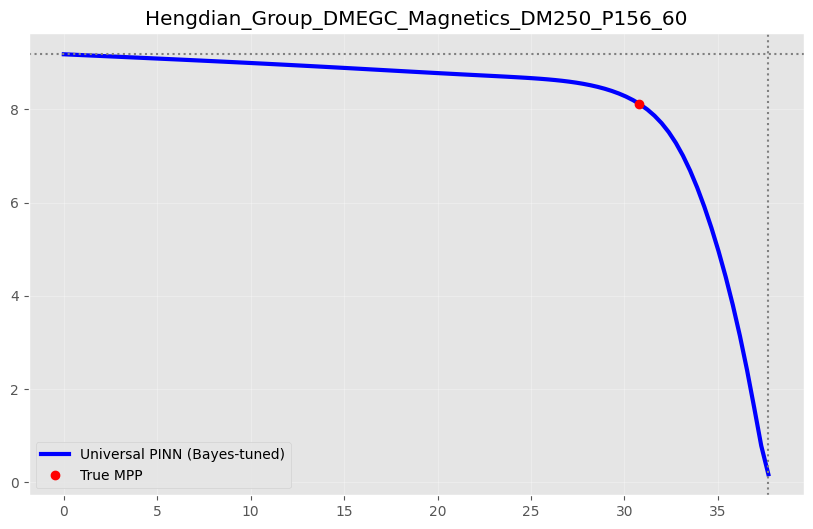

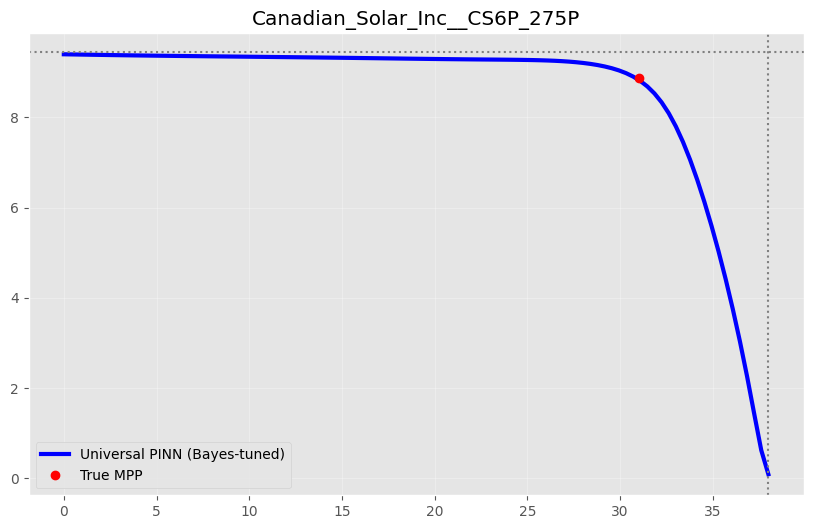

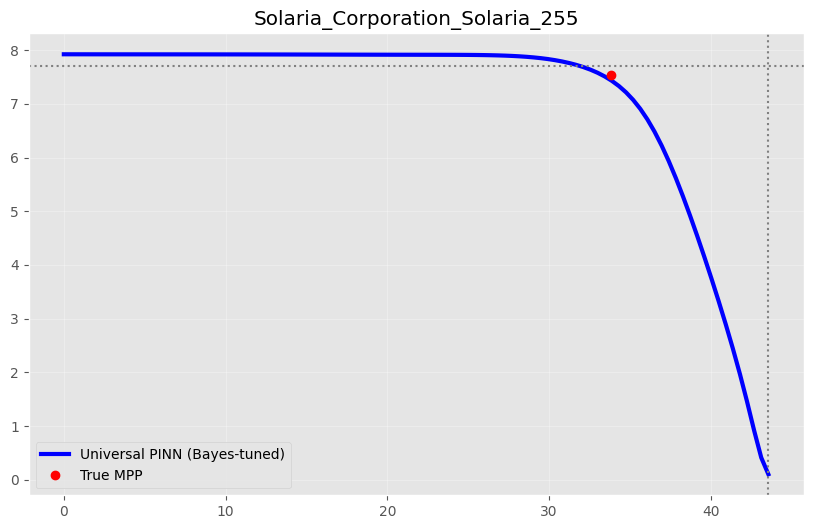

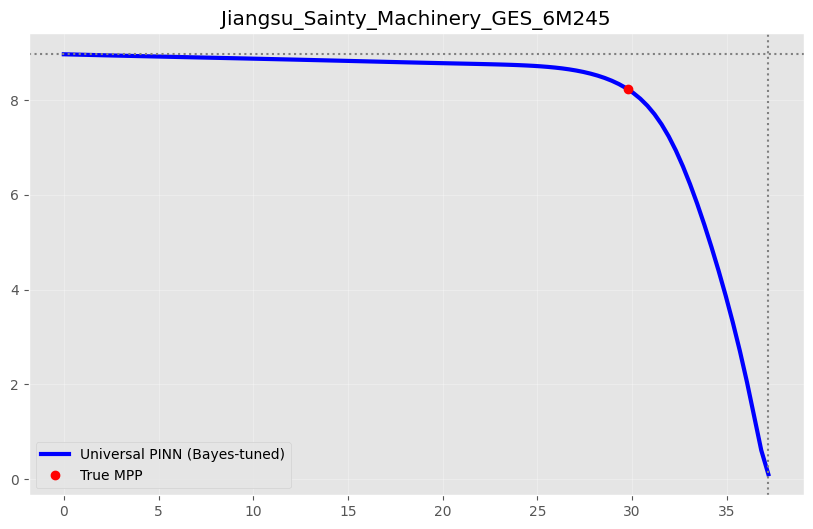

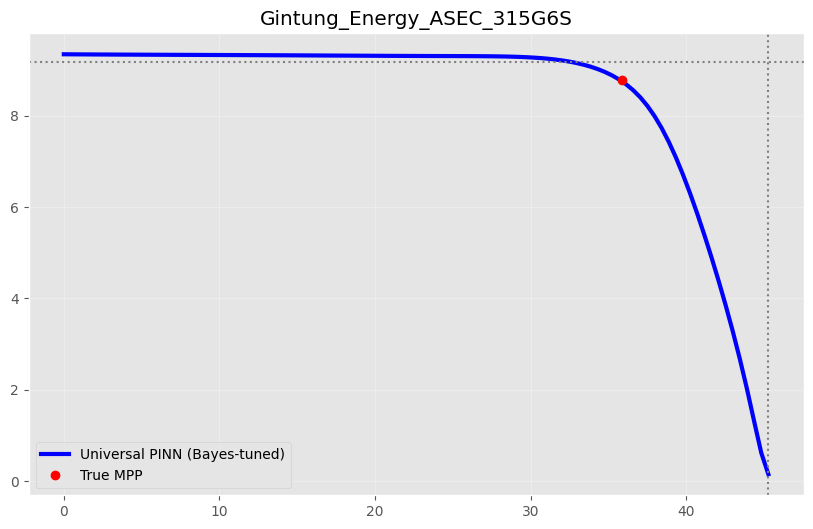

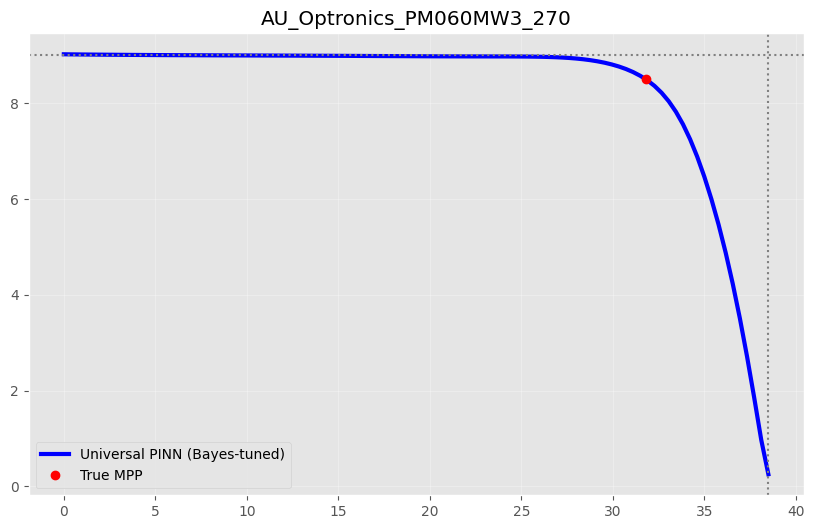

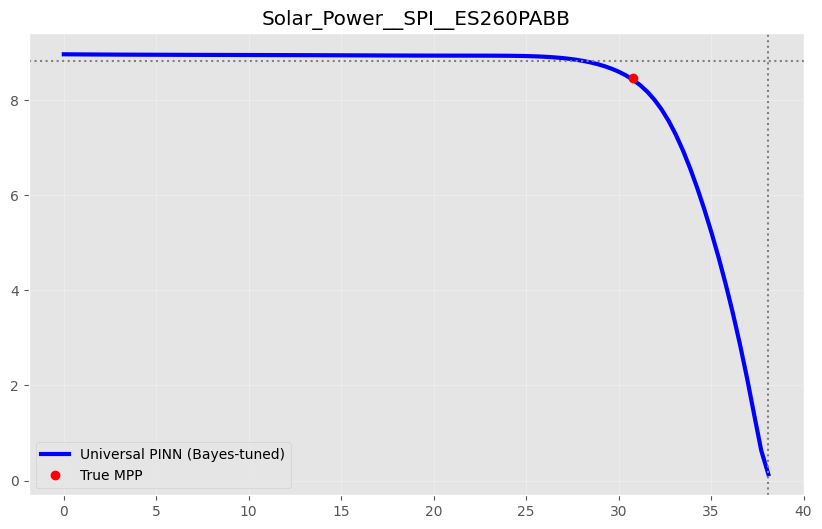

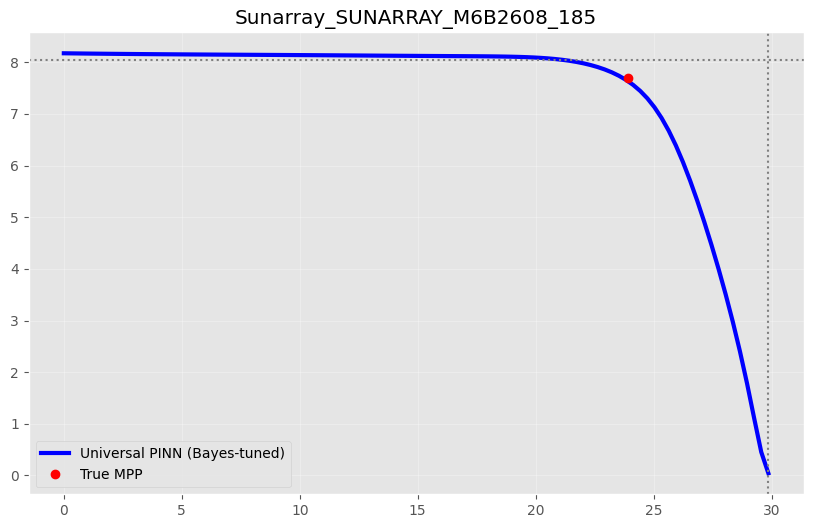

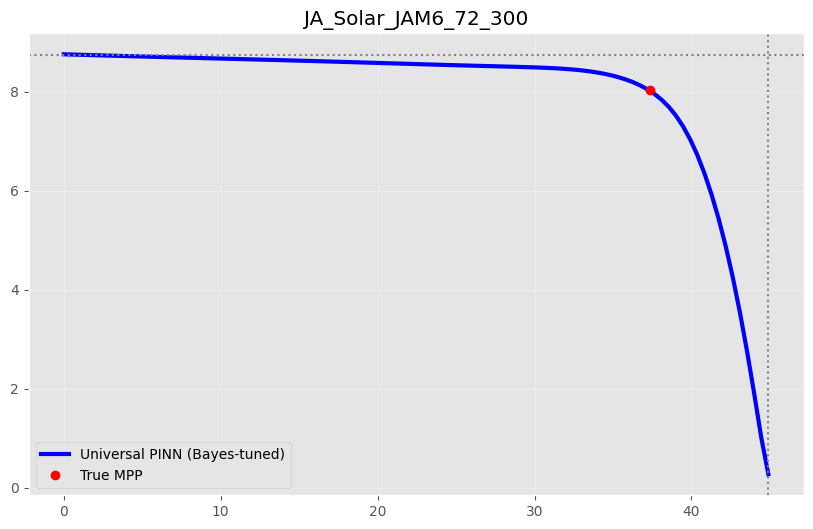

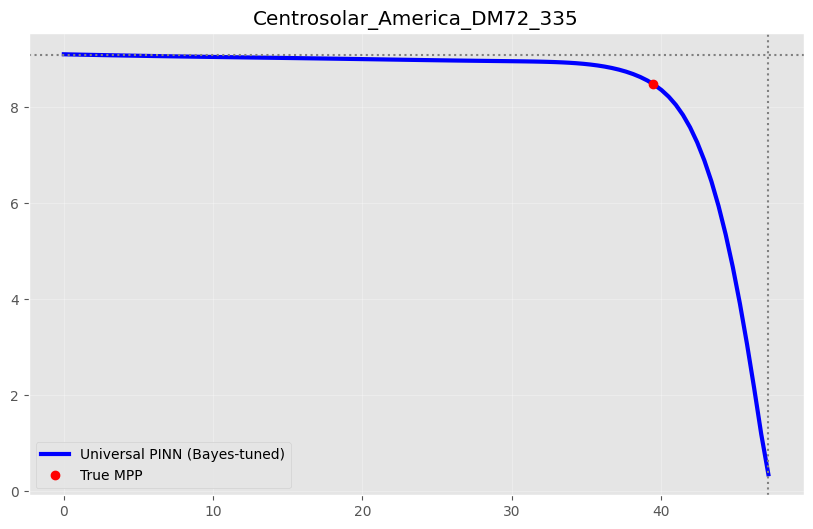

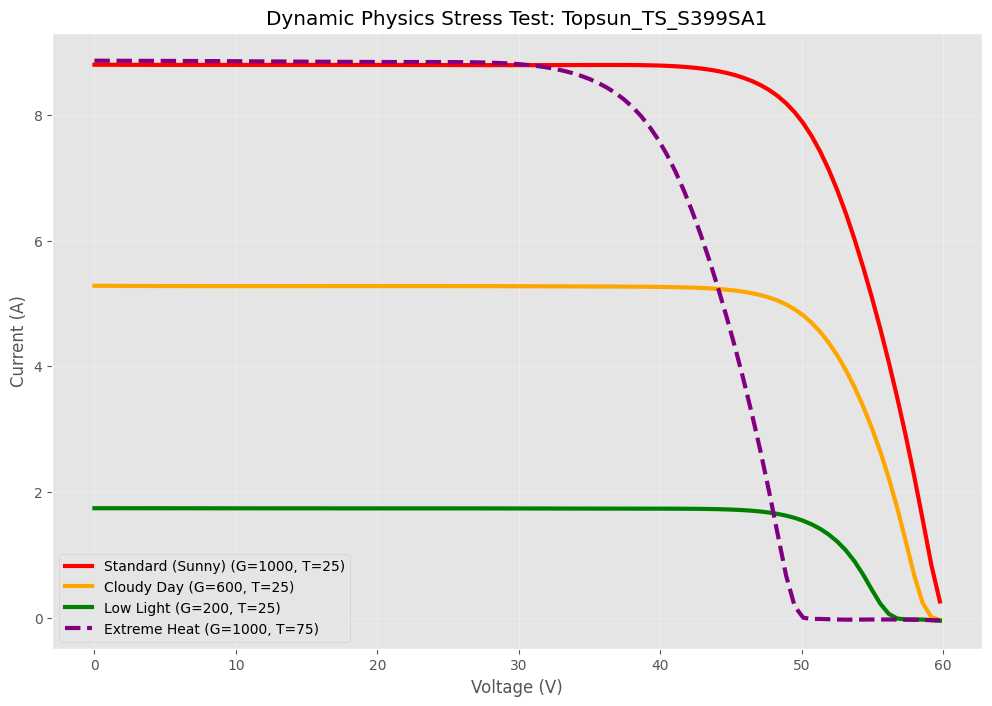

In [9]:
import pvlib
import pandas as pd

# Retrieve the CEC module database
# The result is a pandas DataFrame where module names are the index
cec_modules = pvlib.pvsystem.retrieve_sam('CECMod')

# To see all module names (the index of the DataFrame)
all_module_names = cec_modules.index.tolist()
print("Starting sampling test.......")
for i in range(10):
  test_panel(all_module_names[i])


def stress_test_physics(panel_name):
    try: row = df_db.loc[panel_name]
    except: row = df_db.sample(1).iloc[0]; panel_name = row.name

    # 1. Prepare DNA (Static for this panel)
    dna_vals = [row[c] for c in fit_cols]
    dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
    dna_norm = dna_scaler.transform(dna_df)[0]
    
    # 2. Define 3 Scenarios
    scenarios = [
        {"G": 1000, "T": 25, "Label": "Standard (Sunny)", "Color": "red"},
        {"G": 600,  "T": 25, "Label": "Cloudy Day",       "Color": "orange"},
        {"G": 200,  "T": 25, "Label": "Low Light",        "Color": "green"},
        {"G": 1000, "T": 75, "Label": "Extreme Heat",     "Color": "purple"} # High T should drop Voltage
    ]
    
    plt.figure(figsize=(12, 8))
    
    v_sweep = np.linspace(0, 1.0, 100)
    
    for s in scenarios:
        # Build Inputs: [G_norm, T_norm, V_norm, DNA..., Scalers...]
        X_test = []
        for v in v_sweep:
            X_test.append([
                s["G"]/1000.0,      # G_norm
                (s["T"]-25.0)/100.0,# T_norm
                v                   # Voltage Sweep
            ] + dna_norm.tolist() + [
                row['V_oc_ref']/50.0, 
                row['I_sc_ref']/10.0
            ])
            
        # Predict
        y_pred = model.predict(np.array(X_test, dtype='float32'), verbose=0)
        
        # Denormalize
        I_pred = y_pred.flatten() * row['I_sc_ref']
        V_real = v_sweep * row['V_oc_ref']
        
        # Plot
        style = '--' if s["T"] > 25 else '-'
        plt.plot(V_real, I_pred, label=f"{s['Label']} (G={s['G']}, T={s['T']})", 
                 color=s['Color'], lw=3, linestyle=style)

    plt.title(f"Dynamic Physics Stress Test: {panel_name}")
    plt.xlabel("Voltage (V)")
    plt.ylabel("Current (A)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Test on a random panel
stress_test_physics(df_db.sample(1).index[0])

🚀 STARTING MASSIVE BENCHMARK: 1000 PANELS
Simulating full day for 1000 panels... (Physics vs. PINN)
Processing panel 0/1000...
Processing panel 20/1000...
Processing panel 40/1000...
Processing panel 60/1000...
Processing panel 80/1000...
Processing panel 100/1000...
Processing panel 120/1000...
Processing panel 140/1000...
Processing panel 160/1000...
Processing panel 180/1000...
Processing panel 200/1000...
Processing panel 220/1000...
Processing panel 240/1000...
Processing panel 260/1000...
Processing panel 280/1000...
Processing panel 300/1000...
Processing panel 320/1000...
Processing panel 340/1000...
Processing panel 360/1000...
Processing panel 380/1000...
Processing panel 400/1000...
Processing panel 420/1000...
Processing panel 440/1000...
Processing panel 460/1000...
Processing panel 480/1000...
Processing panel 500/1000...
Processing panel 520/1000...
Processing panel 540/1000...
Processing panel 560/1000...
Processing panel 580/1000...
Processing panel 600/1000...
Process

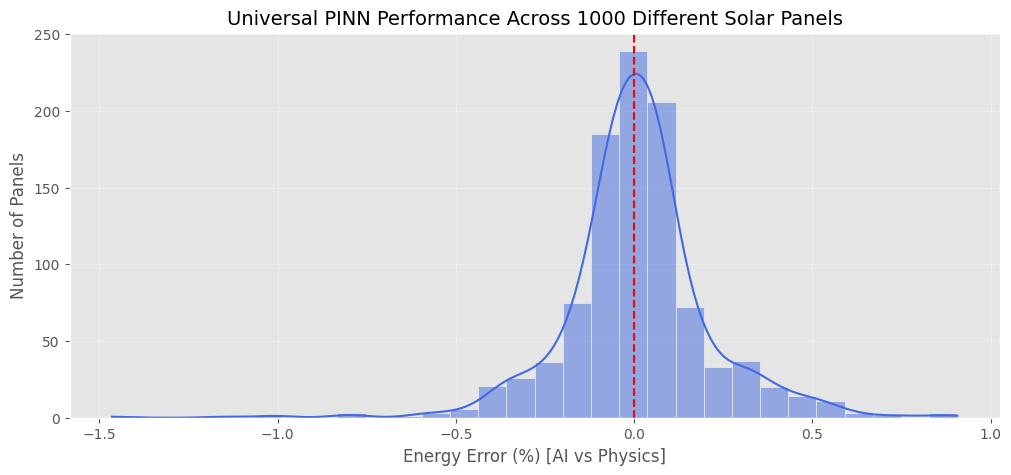

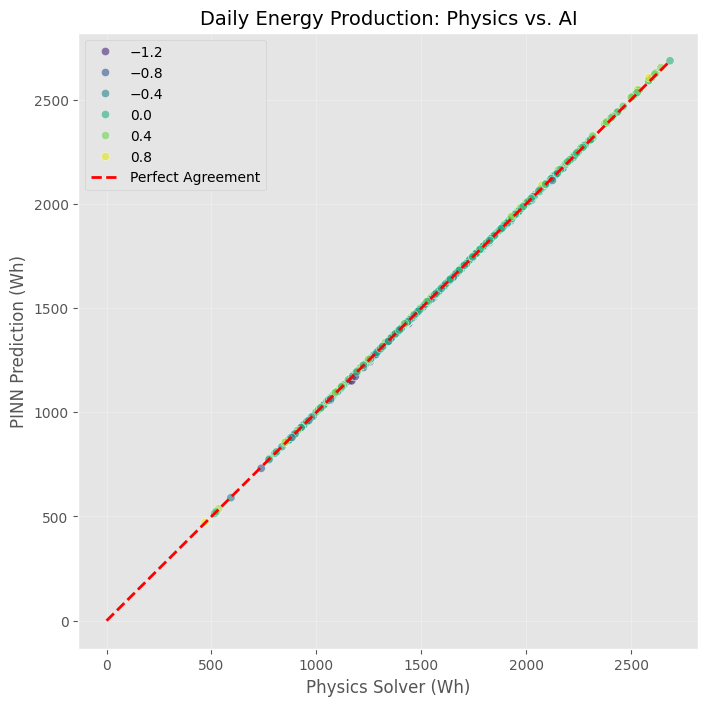


       FINAL SCORECARD       
Panels Tested:      1000
Mean Abs Error:     0.14%
Median Abs Error:   0.08%
95th Percentile:    0.43%


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pvlib import pvsystem

# 1. Suppress the specific Scipy/Numpy warnings that clutter the output
warnings.filterwarnings('ignore', category=RuntimeWarning, module='scipy.optimize')
warnings.filterwarnings('ignore', category=RuntimeWarning, module='numpy')

def run_massive_benchmark(trained_model, n_panels=200):
    print("="*60)
    print(f"🚀 STARTING MASSIVE BENCHMARK: {n_panels} PANELS")
    print("="*60)
   
    # 1. Select Random Panels
    # Ensure we only pick valid rows from the CEC database
    test_indices = np.random.choice(len(df_db), n_panels, replace=False)
   
    # 2. Define the "Test Day" Weather (Same for all panels)
    times = pd.date_range('2025-06-21 06:00', '2025-06-21 18:00', freq='15min')
    N_t = len(times)
   
    # Create weather signals
    x = np.linspace(0, np.pi, N_t)
    g_signal = 1000 * np.sin(x)
    g_signal[20:26] *= 0.4  # Noon cloud
    
    # STABILITY FIX: PVLib solvers can fail at exactly 0 irradiance. 
    # We use a tiny floor (0.1W) for physics calculations.
    g_physics = np.maximum(g_signal, 0.1) 
    
    t_signal = 20 + 30 * np.sin(x) # Simple temp curve (20C to 50C)
   
    # 3. STORAGE FOR RESULTS
    results = []
   
    print(f"Simulating full day for {n_panels} panels... (Physics vs. PINN)")
   
    for i, idx in enumerate(test_indices):
        if i % 20 == 0: print(f"Processing panel {i}/{n_panels}...")
       
        row = df_db.iloc[idx]
        panel_name = row.name
       
        # --- A. PREPARE DNA ---
        dna_vals = [row[c] for c in fit_cols]
        dna_df = pd.DataFrame([dna_vals], columns=fit_cols)
        dna_norm = dna_scaler.transform(dna_df)[0]
       
        # --- B. CALCULATE TRUE ENERGY (PVLIB) ---
        energy_true = 0
        try:
            # We wrap the solver in errstate to ignore the 'divide by zero' warnings 
            # produced by internal Scipy iterations
            with np.errstate(divide='ignore', invalid='ignore'):
                IL, I0, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
                    g_physics, t_signal,
                    row['alpha_sc'], row['a_ref'], row['I_L_ref'],
                    row['I_o_ref'], row['R_sh_ref'], row['R_s']
                )
                
                # Solve for max power point using LambertW
                sol = pvsystem.singlediode(IL, I0, Rs, Rsh, nNsVth, method='lambertw')
                p_mp = sol['p_mp']
                
                # Clean up results (replace NaNs with 0)
                p_mp_clean = np.nan_to_num(p_mp, nan=0.0)
                energy_true = np.sum(p_mp_clean) * 0.25 # 15 min intervals = 0.25 hours
        except Exception:
            continue # Skip panels that cause the physics solver to diverge
           
        if energy_true < 5: continue # Skip broken/tiny panels
           
        # --- C. CALCULATE AI ENERGY (PINN) ---
        # Generate Voltage Sweep [0 to 1 normalized]
        v_res = 50
        v_sweep = np.linspace(0, 1.0, v_res)
       
        # Build Vectorized Batch: [Time * Voltage Sweep, Features]
        G_flat = np.repeat(g_signal/1000.0, v_res)
        T_flat = np.repeat((t_signal-25.0)/100.0, v_res)
        V_flat = np.tile(v_sweep, N_t)
       
        DNA_flat = np.tile(dna_norm, (len(G_flat), 1))
        # SC characteristics for scaling the PINN output
        SC_flat = np.tile([row['V_oc_ref']/50.0, row['I_sc_ref']/10.0], (len(G_flat), 1))
       
        X_batch = np.column_stack([G_flat, T_flat, V_flat, DNA_flat, SC_flat])
       
        # Run AI Inference (Batch process the entire day at once)
        y_pred = trained_model.predict(X_batch, batch_size=8192, verbose=0).flatten()
       
        # Convert AI normalized current back to Power
        i_real = y_pred * row['I_sc_ref']
        v_real = V_flat * row['V_oc_ref']
        p_real = v_real * i_real
       
        # Find peak power for each of the 48 time steps
        p_matrix = p_real.reshape(N_t, v_res)
        ai_p_mp = np.max(p_matrix, axis=1) 
       
        energy_ai = np.sum(ai_p_mp) * 0.25
       
        # --- D. COMPARE ---
        error_pct = (energy_ai - energy_true) / energy_true * 100
       
        results.append({
            "Name": panel_name,
            "Cells": row['N_s'],
            "True_Wh": energy_true,
            "AI_Wh": energy_ai,
            "Error_%": error_pct
        })

    # 4. VISUALIZATION
    df_res = pd.DataFrame(results)
    
    # Filter extreme outliers usually caused by physical solver failures
    df_res = df_res[df_res['Error_%'].abs() < 50]
   
    # Plot 1: Accuracy Distribution
    plt.figure(figsize=(12, 5))
    sns.histplot(df_res['Error_%'], kde=True, color='royalblue', bins=30)
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Universal PINN Performance Across {len(df_res)} Different Solar Panels", fontsize=14)
    plt.xlabel("Energy Error (%) [AI vs Physics]", fontsize=12)
    plt.ylabel("Number of Panels", fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.show()
   
    # Plot 2: Regression Correlation
    plt.figure(figsize=(8, 8))
    sns.scatterplot(data=df_res, x='True_Wh', y='AI_Wh', hue='Error_%', palette='viridis', alpha=0.6)
   
    max_val = max(df_res['True_Wh'].max(), df_res['AI_Wh'].max())
    plt.plot([0, max_val], [0, max_val], 'r--', lw=2, label='Perfect Agreement')
   
    plt.title("Daily Energy Production: Physics vs. AI", fontsize=14)
    plt.xlabel("Physics Solver (Wh)", fontsize=12)
    plt.ylabel("PINN Prediction (Wh)", fontsize=12)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
   
    # 5. FINAL STATS
    mae = df_res['Error_%'].abs().mean()
    print("\n" + "="*30)
    print("       FINAL SCORECARD       ")
    print("="*30)
    print(f"Panels Tested:      {len(df_res)}")
    print(f"Mean Abs Error:     {mae:.2f}%")
    print(f"Median Abs Error:   {df_res['Error_%'].abs().median():.2f}%")
    print(f"95th Percentile:    {df_res['Error_%'].abs().quantile(0.95):.2f}%")
    print("="*30)
   
    return df_res

# RUN THE BENCHMARK
# Note: Ensure 'model', 'df_db', 'fit_cols', and 'dna_scaler' are defined in your workspace.
benchmark_results = run_massive_benchmark(model, n_panels=1000)

No valid --panel given; sampled random panel: Hanwha_SolarOne__Qidong__HSL72P6_PA_0_305T
Computing ground-truth MPP trajectory for Hanwha_SolarOne__Qidong__HSL72P6_PA_0_305T...
Running P&O controller...
Running PINN-based MPPT...


/tmp/ipykernel_57/1609117638.py:269: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(P, dx=dt_hours)



=== Results ===
Theoretical max energy   : 1913.8436 Wh (per-cell relative units)
P&O harvested energy     : 1903.8652 Wh (99.48% of theoretical max)
PINN harvested energy    : 1913.4540 Wh (99.98% of theoretical max)
P&O  RMSE vs true MPP    : 1.576472
PINN RMSE vs true MPP    : 0.071953

Saved plot to po_vs_pinn_comparison.png


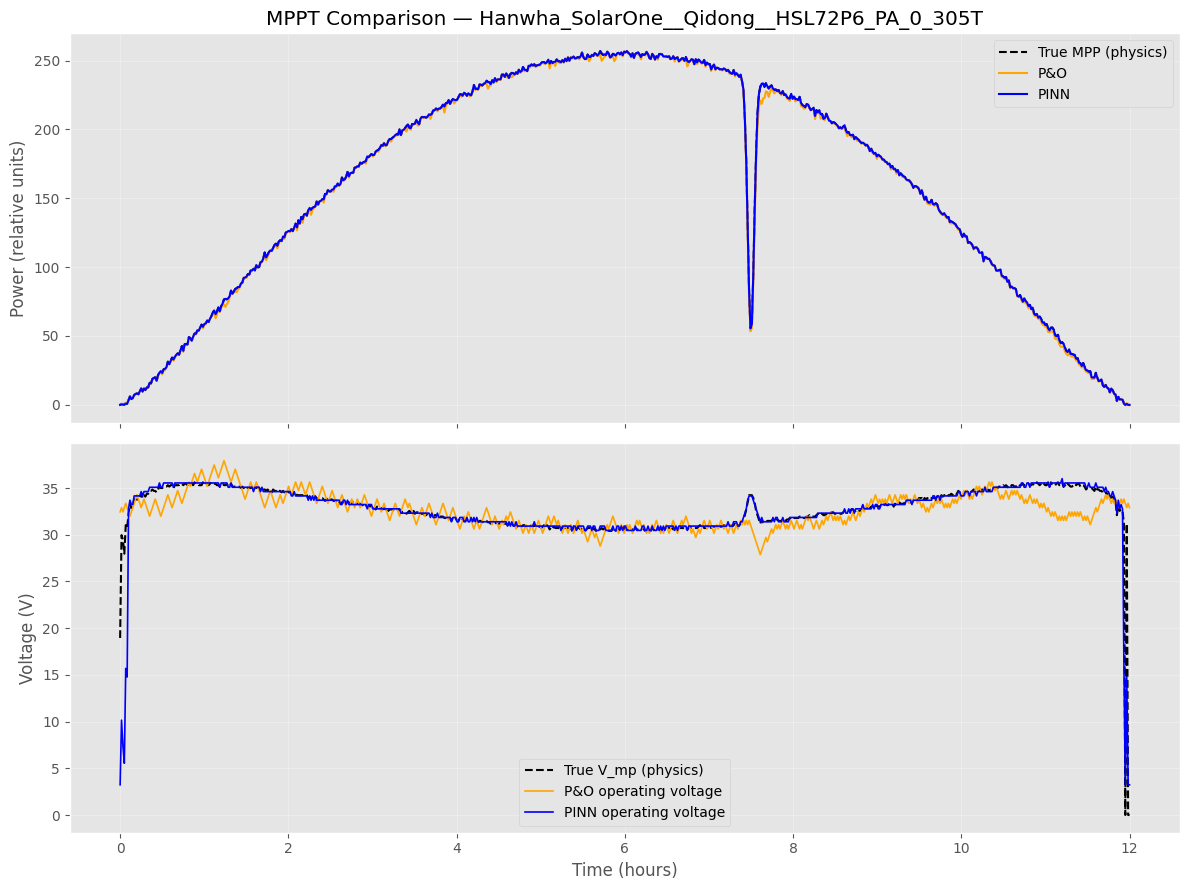

In [11]:
"""
po_vs_pinn_comparison.py

Benchmarks the universal PINN's real-time Maximum Power Point Tracking (MPPT)
against a traditional Perturb & Observe (P&O) controller — the algorithm most
commonly deployed in real-world solar inverters.

Motivation
----------
P&O is simple and doesn't require any model of the panel: at each timestep it
nudges the operating voltage by a small step and observes whether power went
up or down, then continues or reverses direction accordingly. This makes it
robust and easy to implement, but it has two well-known weaknesses:
    1. Steady-state oscillation ("ripple") around the true MPP, since it never
       actually stops perturbing.
    2. Tracking lag during rapidly changing irradiance (e.g. passing clouds),
       since it can only move one small step per timestep and may even step
       in the *wrong* direction momentarily when conditions change mid-perturbation.

The PINN, by contrast, predicts the full I-V curve directly from the current
irradiance/temperature/panel parameters, so it can locate the MPP in a single
forward pass with no iterative search and no oscillation.

This script simulates both controllers tracking the same panel through an
identical dynamic weather profile (including a rapid "cloud notch" transient,
consistent with Test_C) and compares:
    - Tracking accuracy (MAE / RMSE vs. the true physics-based MPP)
    - Energy harvested relative to the theoretical maximum
    - Behavior specifically during the transient event

Usage
-----
    python po_vs_pinn_comparison.py --panel <panel_name> --weights <path_to_weights>

If no panel is given, a random panel is sampled from the CEC database. If no
weights path is given, the script looks for the default trained model at
model/universal_pinn_weights.weights.h5 (adjust DEFAULT_WEIGHTS_PATH below
to match your repo layout).
"""

import argparse

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pvlib
from pvlib import pvsystem
from sklearn.preprocessing import RobustScaler
import tensorflow as tf
from tensorflow import keras

DEFAULT_WEIGHTS_PATH = "model/universal_pinn_weights.weights.h5"

FIT_COLS = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref_log', 'R_s', 'R_sh_ref_log', 'N_s']


# =============================================================================
# 1. PANEL DATABASE / SCALER (mirrors data_loader.py — kept local here so this
#    script can run standalone as a benchmark/demo)
# =============================================================================
def load_panel_database():
    all_modules = pvlib.pvsystem.retrieve_sam('CECMod').T
    df_db = all_modules[all_modules['Technology'].str.contains('Si', na=False)].copy()

    dna_cols = ['alpha_sc', 'a_ref', 'I_L_ref', 'I_o_ref', 'R_s', 'R_sh_ref', 'N_s']
    for col in dna_cols + ['V_oc_ref', 'I_sc_ref', 'V_mp_ref', 'I_mp_ref']:
        df_db[col] = pd.to_numeric(df_db[col], errors='coerce')

    df_db = df_db[
        (df_db['I_o_ref'] > 1e-15) & (df_db['a_ref'] > 0.5) &
        (df_db['R_sh_ref'] > 10.0) & (df_db['I_sc_ref'] > 0.5) &
        (df_db['V_oc_ref'] > 10.0)
    ].dropna(subset=dna_cols)

    df_db['I_o_ref_log'] = np.log10(df_db['I_o_ref'])
    df_db['R_sh_ref_log'] = np.log10(df_db['R_sh_ref'])

    scaler = RobustScaler()
    scaler.fit(df_db[FIT_COLS])

    return df_db, scaler


# =============================================================================
# 2. SYNTHETIC 12-HOUR WEATHER PROFILE WITH A "CLOUD NOTCH" TRANSIENT
# =============================================================================
def generate_weather_profile(n_steps=720, seed=7):
    """Generates a 12-hour irradiance/temperature profile at 1-minute
    resolution (720 steps), with a smooth bell-shaped irradiance curve and a
    rapid transient shadow ("cloud notch") partway through the day."""
    rng = np.random.default_rng(seed)
    t = np.linspace(0, 12, n_steps)  # hours

    # Smooth daytime irradiance curve (peaks at solar noon = hour 6)
    G_clear = 1000 * np.sin(np.pi * t / 12) ** 1.2
    G_clear = np.clip(G_clear, 0, None)

    # Cloud notch: a rapid ~80% irradiance drop lasting a few minutes,
    # centered partway through the afternoon
    notch_center = 7.5  # hours
    notch_width = 0.08  # hours (~5 minutes)
    notch_depth = 0.8
    notch = notch_depth * np.exp(-0.5 * ((t - notch_center) / (notch_width / 2)) ** 2)
    G = G_clear * (1 - notch)

    # Small sensor/measurement noise
    G += rng.normal(0, 5, n_steps)
    G = np.clip(G, 0, 1200)

    # Cell temperature loosely tracks irradiance with thermal lag + ambient rise
    T_ambient = 20 + 10 * np.sin(np.pi * t / 12)
    T_cell = T_ambient + 0.03 * G + rng.normal(0, 0.5, n_steps)

    return t, G, T_cell


# =============================================================================
# 3. GROUND-TRUTH PHYSICS MODEL (De Soto single-diode, via pvlib)
# =============================================================================
def true_iv_curve(row, G, T_c, v_grid):
    """Returns the ground-truth current at each voltage in v_grid, for a
    given panel row and a single (G, T_c) condition, using the De Soto model."""
    IL, Io, Rs, Rsh, nNsVth = pvsystem.calcparams_desoto(
        G, T_c, row['alpha_sc'], row['a_ref'], row['I_L_ref'],
        row['I_o_ref'], row['R_sh_ref'], row['R_s']
    )
    I = pvsystem.i_from_v(v_grid, IL, Io, Rs, Rsh, nNsVth)
    return np.nan_to_num(I, nan=0.0)


def true_mpp(row, G, T_c, n_grid_points=300):
    """Finds the true MPP by a fine-grained sweep of the ground-truth curve.
    This stands in for 'perfect knowledge' — the benchmark against which both
    P&O and the PINN are measured."""
    v_grid = np.linspace(0, row['V_oc_ref'], n_grid_points)
    I = true_iv_curve(row, G, T_c, v_grid)
    P = v_grid * I
    idx = np.argmax(P)
    return v_grid[idx], I[idx], P[idx]


# =============================================================================
# 4. PERTURB & OBSERVE CONTROLLER
# =============================================================================
def run_po_mppt(row, G_series, T_series, dt_seconds=60, v_step_frac=0.01):
    """Simulates a classic P&O controller tracking MPP over time.

    At each timestep, perturbs the operating voltage by a small step in the
    direction that increased power last time, then measures the resulting
    power on the *true* physics curve (as if measured by a real sensor).
    """
    n = len(G_series)
    v_step = v_step_frac * row['V_oc_ref']

    V_track = np.zeros(n)
    P_track = np.zeros(n)

    # Start at an arbitrary voltage (e.g. 70% of Voc — a common cold-start point)
    v_op = 0.7 * row['V_oc_ref']
    direction = 1.0
    prev_power = None

    for k in range(n):
        G, T_c = G_series[k], T_series[k]
        I_op = true_iv_curve(row, G, T_c, np.array([v_op]))[0]
        P_op = v_op * I_op

        if prev_power is not None:
            if P_op < prev_power:
                direction *= -1.0  # power went down: reverse direction

        v_op = np.clip(v_op + direction * v_step, 0.0, row['V_oc_ref'])
        prev_power = P_op

        V_track[k] = v_op
        P_track[k] = P_op

    return V_track, P_track


# =============================================================================
# 5. PINN-BASED MPPT (single forward pass per timestep)
# =============================================================================
def build_model(units1, units2, units3):
    """Must match the architecture used at training time."""
    return keras.Sequential([
        keras.layers.InputLayer(shape=(12,)),
        keras.layers.Dense(units1, activation='swish'),
        keras.layers.Dense(units2, activation='swish'),
        keras.layers.Dense(units3, activation='swish'),
        keras.layers.Dense(1, activation='linear')
    ])


def load_pinn(weights_path, units1=384, units2=224, units3=80):
    """Loads the trained PINN. Adjust units1/2/3 to match whatever
    architecture actually won your Bayesian hyperparameter search."""
    model = build_model(units1, units2, units3)
    model.build(input_shape=(None, 12))
    model.load_weights(weights_path)
    return model


def run_pinn_mppt(model, row, scaler, G_series, T_series, n_grid_points=100):
    """At each timestep, the PINN predicts the full I-V curve directly from
    (G, T, panel DNA) and the operating point is chosen as the predicted
    argmax of power — no iterative search required."""
    dna_vals = [row[c] for c in FIT_COLS]
    dna_df = pd.DataFrame([dna_vals], columns=FIT_COLS)
    dna_norm = scaler.transform(dna_df)[0]

    v_norm_grid = np.linspace(0, 1.0, n_grid_points)
    n = len(G_series)

    V_track = np.zeros(n)
    P_track = np.zeros(n)

    for k in range(n):
        G, T_c = G_series[k], T_series[k]
        G_norm = G / 1000.0
        T_norm = (T_c - 25.0) / 100.0

        X = np.array([
            [G_norm, T_norm, v] + dna_norm.tolist() +
            [row['V_oc_ref'] / 50.0, row['I_sc_ref'] / 10.0]
            for v in v_norm_grid
        ], dtype='float32')

        I_pred_norm = model.predict(X, verbose=0).flatten()
        I_pred = I_pred_norm * row['I_sc_ref']
        V_pred = v_norm_grid * row['V_oc_ref']
        P_pred = V_pred * I_pred

        idx = np.argmax(P_pred)
        v_op = V_pred[idx]

        # Measure the *actual* power achieved at that operating point on the
        # true physics curve (the PINN chooses the setpoint; reality delivers
        # the power, same as with P&O above).
        I_true = true_iv_curve(row, G, T_c, np.array([v_op]))[0]
        P_true = v_op * I_true

        V_track[k] = v_op
        P_track[k] = P_true

    return V_track, P_track


# =============================================================================
# 6. COMPARISON / METRICS / PLOTTING
# =============================================================================
def run_comparison(row, scaler, model, t, G, T_c):
    print(f"Computing ground-truth MPP trajectory for {row.name}...")
    P_true = np.zeros(len(t))
    V_true = np.zeros(len(t))
    for k in range(len(t)):
        v_mpp, _, p_mpp = true_mpp(row, G[k], T_c[k])
        V_true[k] = v_mpp
        P_true[k] = p_mpp

    print("Running P&O controller...")
    V_po, P_po = run_po_mppt(row, G, T_c)

    print("Running PINN-based MPPT...")
    V_pinn, P_pinn = run_pinn_mppt(model, row, scaler, G, T_c)

    # --- Metrics ---
    def energy_wh(P, dt_hours):
        return np.trapz(P, dx=dt_hours)

    dt_hours = (t[1] - t[0])
    energy_true = energy_wh(P_true, dt_hours)
    energy_po = energy_wh(P_po, dt_hours)
    energy_pinn = energy_wh(P_pinn, dt_hours)

    rmse_po = np.sqrt(np.mean((P_po - P_true) ** 2))
    rmse_pinn = np.sqrt(np.mean((P_pinn - P_true) ** 2))

    print("\n=== Results ===")
    print(f"Theoretical max energy   : {energy_true:.4f} Wh (per-cell relative units)")
    print(f"P&O harvested energy     : {energy_po:.4f} Wh "
          f"({100 * energy_po / energy_true:.2f}% of theoretical max)")
    print(f"PINN harvested energy    : {energy_pinn:.4f} Wh "
          f"({100 * energy_pinn / energy_true:.2f}% of theoretical max)")
    print(f"P&O  RMSE vs true MPP    : {rmse_po:.6f}")
    print(f"PINN RMSE vs true MPP    : {rmse_pinn:.6f}")

    # --- Plot ---
    fig, axes = plt.subplots(2, 1, figsize=(12, 9), sharex=True)

    axes[0].plot(t, P_true, 'k--', lw=1.5, label='True MPP (physics)')
    axes[0].plot(t, P_po, color='orange', lw=1.5, label='P&O')
    axes[0].plot(t, P_pinn, color='blue', lw=1.5, label='PINN')
    axes[0].set_ylabel('Power (relative units)')
    axes[0].set_title(f'MPPT Comparison — {row.name}')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(t, V_true, 'k--', lw=1.5, label='True V_mp (physics)')
    axes[1].plot(t, V_po, color='orange', lw=1.2, label='P&O operating voltage')
    axes[1].plot(t, V_pinn, color='blue', lw=1.2, label='PINN operating voltage')
    axes[1].set_xlabel('Time (hours)')
    axes[1].set_ylabel('Voltage (V)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('po_vs_pinn_comparison.png', dpi=150)
    print("\nSaved plot to po_vs_pinn_comparison.png")
    plt.show()

    return {
        'energy_true': energy_true,
        'energy_po': energy_po,
        'energy_pinn': energy_pinn,
        'rmse_po': rmse_po,
        'rmse_pinn': rmse_pinn,
    }


# =============================================================================
# MAIN
# =============================================================================
if __name__ == "__main__":
    parser = argparse.ArgumentParser(description="Compare P&O vs PINN MPPT tracking.")
    parser.add_argument("--panel", type=str, default=None,
                         help="Panel name (index in the CEC database). Random if omitted.")
    parser.add_argument("--weights", type=str, default=DEFAULT_WEIGHTS_PATH,
                         help="Path to trained PINN weights.")
    # parse_known_args (not parse_args) so this also runs cleanly inside
    # Colab/Jupyter, which injects its own kernel-launcher flags (e.g. -f ...)
    # into sys.argv that this script doesn't need to know about.
    args, _unknown = parser.parse_known_args()

    df_db, scaler = load_panel_database()

    if args.panel is not None and args.panel in df_db.index:
        row = df_db.loc[args.panel]
    else:
        row = df_db.sample(1).iloc[0]
        print(f"No valid --panel given; sampled random panel: {row.name}")

    model = load_pinn(args.weights)

    t, G, T_c = generate_weather_profile()
    run_comparison(row, scaler, model, t, G, T_c)